Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
    accuracy_score
)

Config

In [2]:
sns.set_theme(style="whitegrid")

PALETTE = {
    "primary": "#4C72B0",
    "secondary": "#55A868",
    "accent": "#C44E52",
    "neutral": "#8172B2"
}

RANDOM_STATE = 42

Load Data

In [3]:
def load_data():
    path = "/content/Telco-Customer-Churn.csv"

    if os.path.exists(path):
        print(f"Loading dataset from: {path}")
        return pd.read_csv(path)

    raise FileNotFoundError("Dataset not found.")

df = load_data()

Loading dataset from: /content/Telco-Customer-Churn.csv


Data Cleaning

In [4]:
def clean_data(df):
    df = df.copy()

    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df = df.dropna()

    if 'customerID' in df.columns:
        df = df.drop(columns=['customerID'])

    return df

df = clean_data(df)

#Feature Engineering

In [5]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 60, 100],
    labels=['0-12', '12-24', '24-60', '60+']
)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include=['object', 'category']).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# EDA

Churn Distribution

/tmp/ipykernel_47491/3496998758.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=[PALETTE["secondary"], PALETTE["accent"]])


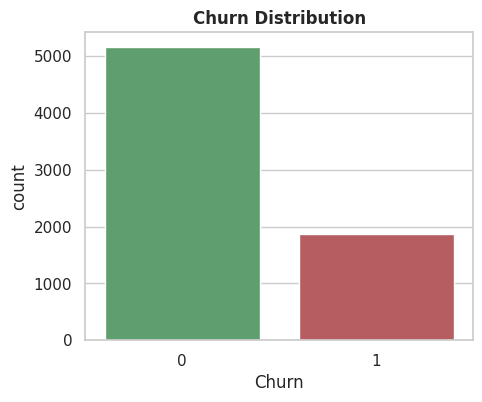

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df, palette=[PALETTE["secondary"], PALETTE["accent"]])
plt.title("Churn Distribution", fontsize=12, fontweight='bold')
plt.show()

Tenure vs Churn

/tmp/ipykernel_47491/4266570804.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette=[PALETTE["secondary"], PALETTE["accent"]])


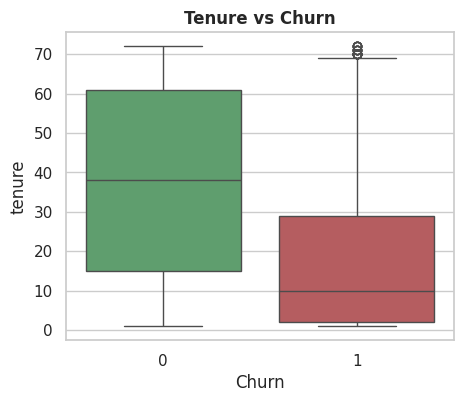

In [7]:
plt.figure(figsize=(5,4))
sns.boxplot(x='Churn', y='tenure', data=df, palette=[PALETTE["secondary"], PALETTE["accent"]])
plt.title("Tenure vs Churn", fontsize=12, fontweight='bold')
plt.show()

Monthly Charges vs Churn

/tmp/ipykernel_47491/3847576436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=[PALETTE["secondary"], PALETTE["accent"]])


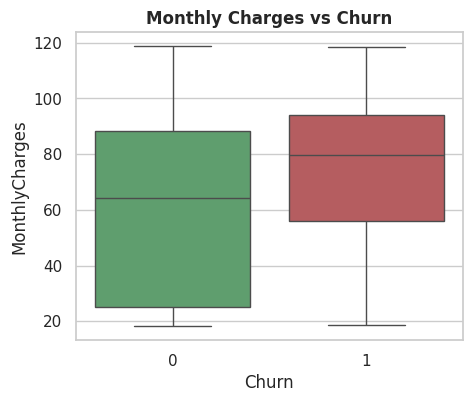

In [8]:
plt.figure(figsize=(5,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=[PALETTE["secondary"], PALETTE["accent"]])
plt.title("Monthly Charges vs Churn", fontsize=12, fontweight='bold')
plt.show()

Split Data

In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

Model

In [10]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

#Evaluation

In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=== MODEL PERFORMANCE ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}\n")

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== MODEL PERFORMANCE ===
Accuracy  : 0.7910
ROC AUC   : 0.8192

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Confusion Matrix

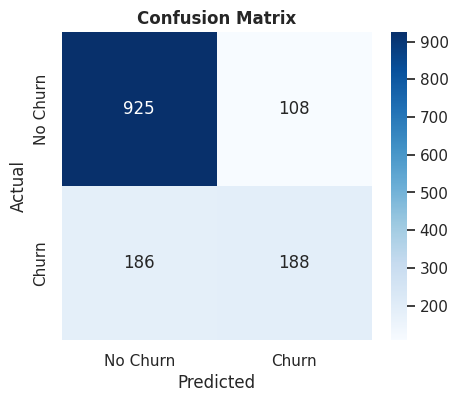

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.title("Confusion Matrix", fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC Curve

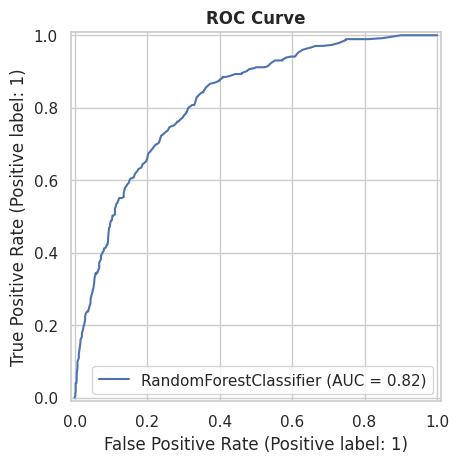

In [13]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve", fontweight='bold')
plt.show()

#Feature Importance

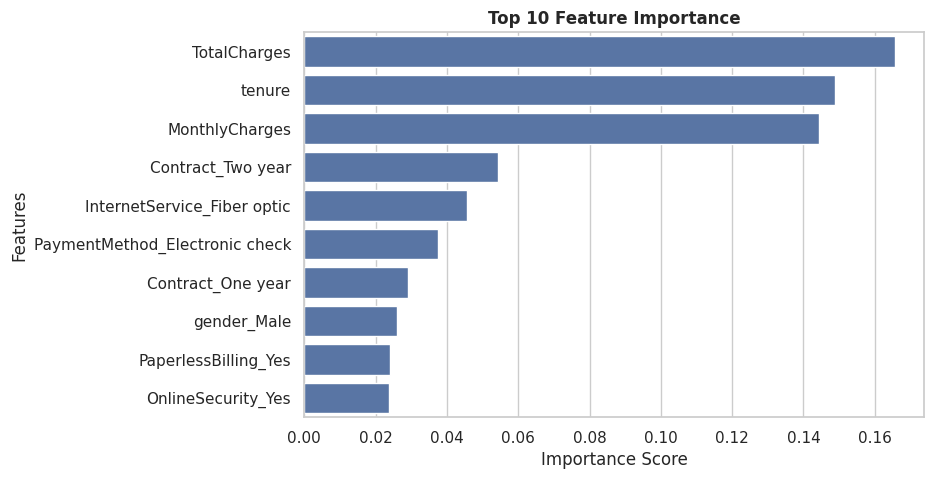


Top 10 Features:
1. TotalCharges (0.1656)
2. tenure (0.1490)
3. MonthlyCharges (0.1444)
4. Contract_Two year (0.0544)
5. InternetService_Fiber optic (0.0457)
6. PaymentMethod_Electronic check (0.0376)
7. Contract_One year (0.0291)
8. gender_Male (0.0261)
9. PaperlessBilling_Yes (0.0240)
10. OnlineSecurity_Yes (0.0238)


In [14]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
    color=PALETTE["primary"]
)
plt.title("Top 10 Feature Importance", fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

print("\nTop 10 Features:")
for i, (feature, value) in enumerate(top_features.items(), 1):
    print(f"{i}. {feature} ({value:.4f})")

Cross Validation

In [15]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')

print(f"\nCross Validation ROC AUC: {cv_scores.mean():.4f}")


Cross Validation ROC AUC: 0.8234


In [ ]:
import joblib

joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [ ]:
model = joblib.load("churn_model.pkl")

In [ ]:
from google.colab import files
files.download('/content/churn_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>